# The handover

Built from [`ROADMAP_PM_HANDOVER.md`](../ROADMAP_PM_HANDOVER.md), the execution plan for project 03. There is no separate design specification for this project (unlike projects 01 and 02): visual decisions not already settled elsewhere are made and justified in this notebook, `ARCHITECTURE.md`, and the project README, following the same method used for `STYLE_DUEL.md`'s one substitution and `THEMATIC_HEATMAP.md`'s two.

This notebook loads artifacts already computed by [`hansard-pm-nlp`](https://github.com/RedaAllab/hansard-pm-nlp) (Phase 7's `event_study_dataset.parquet`) and PM tenure dates (`data/input/pm_tenures.parquet`). No model is retrained and no per-document text is reprocessed.

In [1]:
from pathlib import Path

from hansard_pm_portfolio import data_access as da
from hansard_pm_portfolio.viz import pm_handover as viz
from hansard_pm_portfolio.viz.common import plot_banner, save

ASSETS_DIR = Path("../portfolio/03_pm_handover/assets")
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

## 0. README banner

In [2]:
fig = plot_banner("The handover", "hansard-pm-portfolio, project 03")
save(fig, ASSETS_DIR / "banner.png")
fig

<Figure size 800x200 with 0 Axes>

<Figure size 800x200 with 0 Axes>

## 1. Load the event-study table and derive the 3 transitions

- `event_study_dataset.parquet` (Phase 7): one row per (PM, sitting date), 296 sittings, all 4 in-scope PMs including Liz Truss (unlike Phase 6's classifier) - built in `hansard-pm-nlp` for its own PM x crisis regressions, reused here unchanged.
- The 3 transitions (Johnson to Truss, Truss to Sunak, Sunak to Starmer) are derived from `load_pm_tenures()`, not hardcoded, so a scope change propagates automatically.

In [3]:
events = da.load_event_study_dataset()
transitions = da.load_pm_transitions()
tenures = da.load_pm_tenures()
print(f"{len(events)} sittings, {len(transitions)} transitions")
transitions

296 sittings, 3 transitions


,before_pm,after_pm,transition_date
0,Boris Johnson,Liz Truss,2022-09-06
1,Liz Truss,Rishi Sunak,2022-10-25
2,Rishi Sunak,Keir Starmer,2024-07-05


## 2. The two metrics: why not MTLD

`ROADMAP_PM_HANDOVER.md` section 0 suggests pairing MTLD with `net_certainty`. MTLD is a whole-corpus statistic (see `THEMATIC_METRICS` note in `ARCHITECTURE.md`): McCarthy & Jarvis's segment algorithm needs long, continuous text to be stable, and a single sitting is far too short a unit. Computing it at sitting-date granularity would also mean new computation this repo otherwise avoids.

`vader_compound` is used instead: already computed per sitting date for all 4 PMs in `event_study_dataset.parquet`, zero new computation, and it reads as a genuinely different axis (sentiment) rather than a second style metric, matching this project's own stated objective of comparing "style and sentiment".

In [4]:
da.HANDOVER_METRICS

[('net_certainty', 'Net certainty'), ('vader_compound', 'Sentiment (VADER)')]

## 3. Build the +/- 6 week windows around each transition

A fixed window, not stretched to backfill a thin side (`ROADMAP_PM_HANDOVER.md` section 3: "ne pas étirer artificiellement l'axe pour masquer le faible volume de données"). Two distinct causes leave a side sparse or empty, both kept visible:

- Liz Truss's 49-day tenure is shorter than 2x the window, so it cannot fill either side symmetrically (anticipated in the roadmap).
- Summer recess (before Johnson to Truss) and the Parliament dissolution ahead of the 2024 general election (before Sunak to Starmer) leave the "before" side at **zero** sittings within the strict 6-week window for both of those transitions - a real gap in when Parliament sat, not a data problem, and not anticipated in the roadmap's own text.

In [5]:
windows = da.build_transition_windows(events, transitions)
windows.groupby(["transition_label", "side"]).size()

transition_label  side  
Johnson to Truss  after     4
Sunak to Starmer  after     4
Truss to Sunak    after     6
                  before    2
dtype: int64

## 4. The mini-budget overlap

The Truss to Sunak transition (2022-10-25) falls right after the mini-budget crisis window (2022-09-23 to 2022-10-17). One sitting, 2022-10-12, sits inside both: the "before" side of this transition, and the mini-budget crisis. PM effect and crisis effect are not separable there - flagged on the chart itself, not only in this caption.

In [6]:
in_mini_budget = windows["sitting_date"].apply(
    lambda d: da.in_crisis_window(d, "mini_budget")
)
mini_budget_sittings = windows[in_mini_budget]
cols = ["transition_label", "side", "sitting_date", "net_certainty", "vader_compound"]
mini_budget_sittings[cols]

,transition_label,side,sitting_date,net_certainty,vader_compound
3,Johnson to Truss,after,2022-10-12,0.004844,0.676806
4,Truss to Sunak,before,2022-10-12,0.004844,0.676806


## 5. The main visual: 3 panels, one per transition

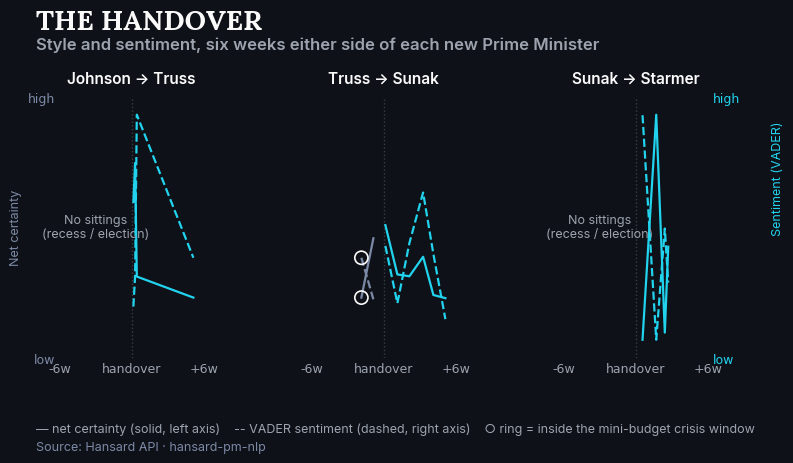

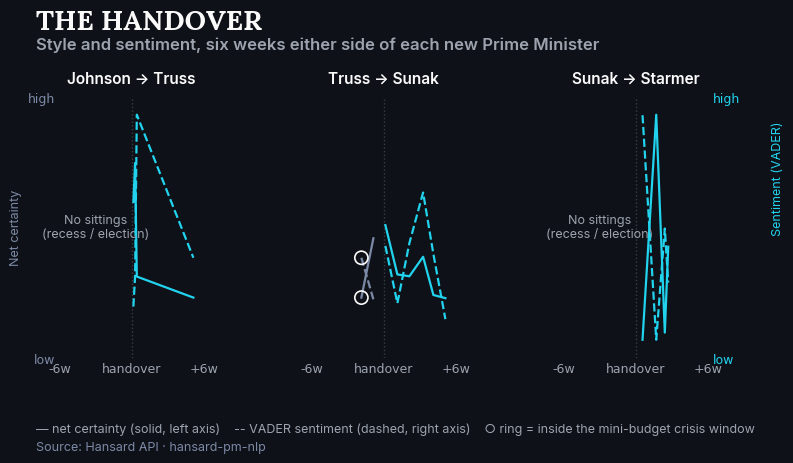

In [7]:
fig = viz.plot_transition_panels(windows, transitions)
save(fig, ASSETS_DIR / "transition_main.png")
fig

## 6. The secondary visual: the same story without the zoom

A continuous monthly view across the full 2019-2026 corpus, both metrics pooled across all in-scope PMs, transition dates marked - for the reader who wants the whole-corpus context rather than 3 isolated zooms.

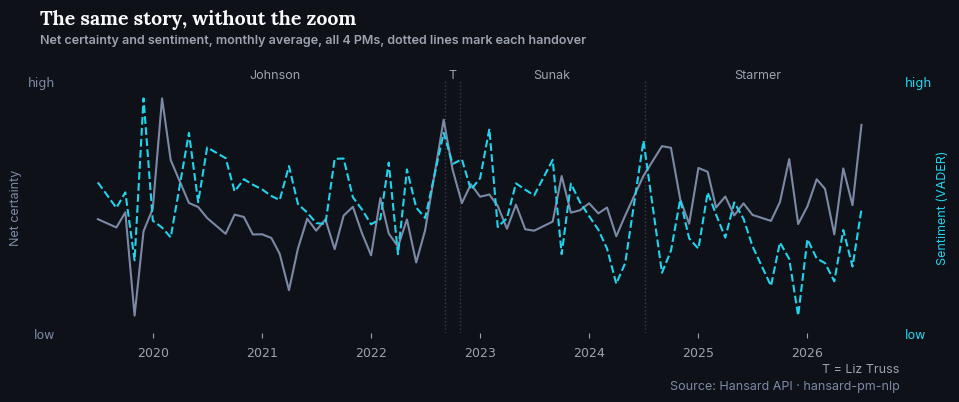

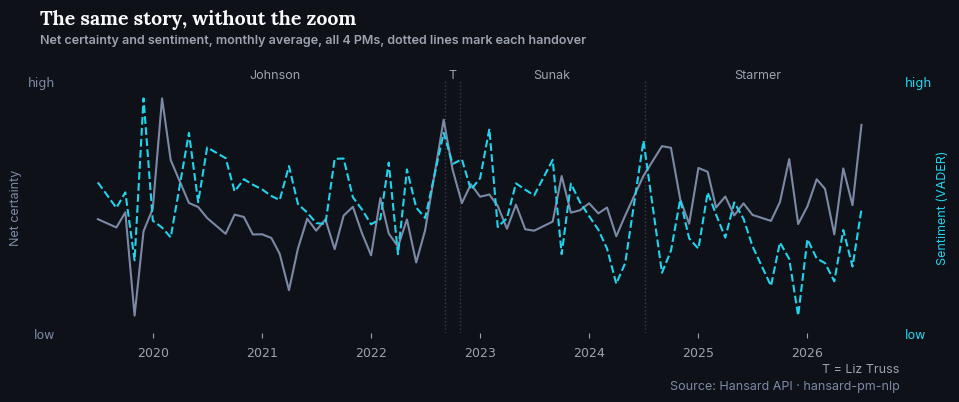

In [8]:
monthly = da.monthly_handover_metrics(events)
fig = viz.plot_transition_timeline(monthly, tenures)
save(fig, ASSETS_DIR / "transition_timeline_secondary.png")
fig

## Links

- Execution plan: [`ROADMAP_PM_HANDOVER.md`](../ROADMAP_PM_HANDOVER.md)
- Event-study source table: [`event_study_dataset.parquet`](https://github.com/RedaAllab/hansard-pm-nlp/tree/main/data/processed) and its report, [`phase7_event_study_report.md`](https://github.com/RedaAllab/hansard-pm-nlp/blob/main/data/processed/phase7_event_study_report.md) (in `hansard-pm-nlp`)
- Architecture decisions: [`ARCHITECTURE.md`](../ARCHITECTURE.md)
- Project README: [`portfolio/03_pm_handover/README.md`](../portfolio/03_pm_handover/README.md)